# Diabetes Prediction Project
This notebook explores the Pima Indians Diabetes dataset, performs data cleaning, and builds classification models to predict diabetes outcomes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
! pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

## 1. Data Loading
Loading the dataset and performing initial inspection.

In [2]:
df = pd.read_csv("diabetes.csv")
print(df.head())
print()
print(df.info())
print()
print(df.describe())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   76

## 2. Data Preprocessing
Handling missing values (zeros) by replacing them with the median of their respective columns.

In [3]:
Columns_with_Zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in Columns_with_Zero:
    df[col] = df[col].replace(0, np.nan)

for col in Columns_with_Zero:
    df[col] = df[col].fillna(df[col].median())

In [4]:
X = df.drop("Outcome", axis=1)
Y = df['Outcome']
print("Class balance:\n", Y.value_counts())

Class balance:
 Outcome
0    500
1    268
Name: count, dtype: int64


## 3. Exploratory Data Analysis
Visualizing feature correlations to understand relationships between variables.

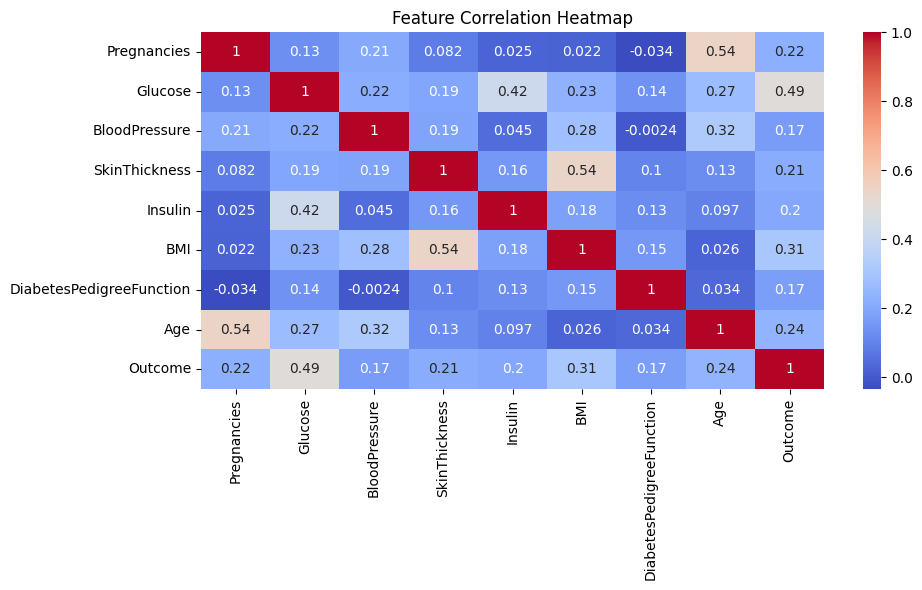

In [5]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 4. Model Building & Evaluation
Splitting the data and training various models, including Logistic Regression, Decision Trees, and Random Forests, while addressing class imbalance.

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y , train_size=0.8, random_state=42, stratify=Y)

In [7]:
results = []

def evaluate_model(name, model, X_train, Y_train, X_test, Y_test):
    train_acc = accuracy_score(Y_train, model.predict(X_train))
    Y_pred = model.predict(X_test)
    test_acc = accuracy_score(Y_test, Y_pred)
    cm = confusion_matrix(Y_test, Y_pred)
    cr = classification_report(Y_test, Y_pred)

    print(f"===== {name} =====")
    print(f"Train Accuracy: {round(train_acc*100, 2)}%")
    print(f"Test Accuracy:  {round(test_acc*100, 2)}%")
    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n", cr)

    return {"name": name, "train_acc": train_acc, "test_acc": test_acc, "cm": cm, "report": cr}

In [8]:
LRModel_plain = LogisticRegression(max_iter=1000, random_state=42)
LRModel_plain.fit(X_train, Y_train)
results.append(evaluate_model("Logistic Regression (Plain)", LRModel_plain, X_train, Y_train, X_test, Y_test))

===== Logistic Regression (Plain) =====
Train Accuracy: 79.32%
Test Accuracy:  70.13%

Confusion Matrix:
 [[81 19]
 [27 27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.81      0.78       100
           1       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



In [9]:
DTModel_plain = DecisionTreeClassifier(max_depth=5, random_state=42)
DTModel_plain.fit(X_train, Y_train)
results.append(evaluate_model("Decision Tree (Plain)", DTModel_plain, X_train, Y_train, X_test, Y_test))

===== Decision Tree (Plain) =====
Train Accuracy: 81.43%
Test Accuracy:  75.97%

Confusion Matrix:
 [[78 22]
 [15 39]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.78      0.81       100
           1       0.64      0.72      0.68        54

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.76      0.76       154



In [10]:
DTModel_balanced = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced")
DTModel_balanced.fit(X_train, Y_train)
results.append(evaluate_model("Decision Tree (Balanced)", DTModel_balanced, X_train, Y_train, X_test, Y_test))

===== Decision Tree (Balanced) =====
Train Accuracy: 83.88%
Test Accuracy:  72.73%

Confusion Matrix:
 [[79 21]
 [21 33]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.79      0.79       100
           1       0.61      0.61      0.61        54

    accuracy                           0.73       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



In [11]:
RFModel_plain = RandomForestClassifier(n_estimators=20, random_state=42, max_depth=5)
RFModel_plain.fit(X_train, Y_train)
results.append(evaluate_model("Random Forest (Plain)", RFModel_plain, X_train, Y_train, X_test, Y_test))

===== Random Forest (Plain) =====
Train Accuracy: 84.53%
Test Accuracy:  72.08%

Confusion Matrix:
 [[84 16]
 [27 27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.84      0.80       100
           1       0.63      0.50      0.56        54

    accuracy                           0.72       154
   macro avg       0.69      0.67      0.68       154
weighted avg       0.71      0.72      0.71       154



### Handling Class Imbalance with SMOTE
Using Synthetic Minority Over-sampling Technique (SMOTE) to balance the training classes and re-running the models with resampled train data.

In [12]:
smote = SMOTE(random_state=42)
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train, Y_train)
print(Y_train.value_counts())
print(Y_train_resampled.value_counts())

Outcome
0    400
1    214
Name: count, dtype: int64
Outcome
0    400
1    400
Name: count, dtype: int64


In [13]:
DTModel_SMOTE = DecisionTreeClassifier(max_depth=5, random_state=42)
DTModel_SMOTE.fit(X_train_resampled, Y_train_resampled)
results.append(evaluate_model("Decision Tree (SMOTE)", DTModel_SMOTE, X_train_resampled, Y_train_resampled, X_test, Y_test))

===== Decision Tree (SMOTE) =====
Train Accuracy: 84.25%
Test Accuracy:  75.97%

Confusion Matrix:
 [[77 23]
 [14 40]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.77      0.81       100
           1       0.63      0.74      0.68        54

    accuracy                           0.76       154
   macro avg       0.74      0.76      0.75       154
weighted avg       0.77      0.76      0.76       154



In [14]:
LRModel_SMOTE = LogisticRegression(max_iter=1000, random_state=42)
LRModel_SMOTE.fit(X_train_resampled, Y_train_resampled)
results.append(evaluate_model("Logistic Regression (SMOTE)", LRModel_SMOTE, X_train_resampled, Y_train_resampled, X_test, Y_test))

===== Logistic Regression (SMOTE) =====
Train Accuracy: 74.38%
Test Accuracy:  71.43%

Confusion Matrix:
 [[74 26]
 [18 36]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.58      0.67      0.62        54

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.70       154
weighted avg       0.73      0.71      0.72       154



In [15]:
DTModel_SMOTE_CCW = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight={0:1, 1:2})
DTModel_SMOTE_CCW.fit(X_train_resampled, Y_train_resampled)
results.append(evaluate_model("Decision Tree (SMOTE + Custom Weights)", DTModel_SMOTE_CCW, X_train_resampled, Y_train_resampled, X_test, Y_test))

===== Decision Tree (SMOTE + Custom Weights) =====
Train Accuracy: 82.0%
Test Accuracy:  72.08%

Confusion Matrix:
 [[66 34]
 [ 9 45]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.66      0.75       100
           1       0.57      0.83      0.68        54

    accuracy                           0.72       154
   macro avg       0.72      0.75      0.72       154
weighted avg       0.77      0.72      0.73       154



In [16]:
RFModel_SMOTE = RandomForestClassifier(n_estimators=20, random_state=42, max_depth=5)
RFModel_SMOTE.fit(X_train_resampled, Y_train_resampled)
results.append(evaluate_model("Random Forest (SMOTE)", RFModel_SMOTE, X_train_resampled, Y_train_resampled, X_test, Y_test))

===== Random Forest (SMOTE) =====
Train Accuracy: 86.5%
Test Accuracy:  75.32%

Confusion Matrix:
 [[74 26]
 [12 42]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.74      0.80       100
           1       0.62      0.78      0.69        54

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.78      0.75      0.76       154



In [17]:
print("======== Model Comparision Summmary =========")
for r in results:
    print(f"\nModel : {r['name']}")
    print(f"Train Accuracy : {round(r['train_acc']*100, 2)}%")
    print(f"Test Accuracy : {round(r['test_acc']*100, 2)}%")

======== Model Comparision Summmary =========

Model : Logistic Regression (Plain)
Train Accuracy : 79.32%
Test Accuracy : 70.13%

Model : Decision Tree (Plain)
Train Accuracy : 81.43%
Test Accuracy : 75.97%

Model : Decision Tree (Balanced)
Train Accuracy : 83.88%
Test Accuracy : 72.73%

Model : Random Forest (Plain)
Train Accuracy : 84.53%
Test Accuracy : 72.08%

Model : Decision Tree (SMOTE)
Train Accuracy : 84.25%
Test Accuracy : 75.97%

Model : Logistic Regression (SMOTE)
Train Accuracy : 74.38%
Test Accuracy : 71.43%

Model : Decision Tree (SMOTE + Custom Weights)
Train Accuracy : 82.0%
Test Accuracy : 72.08%

Model : Random Forest (SMOTE)
Train Accuracy : 86.5%
Test Accuracy : 75.32%


### Feature Importance
Let's visualize which features are most important according to Plain Decision Tree model.

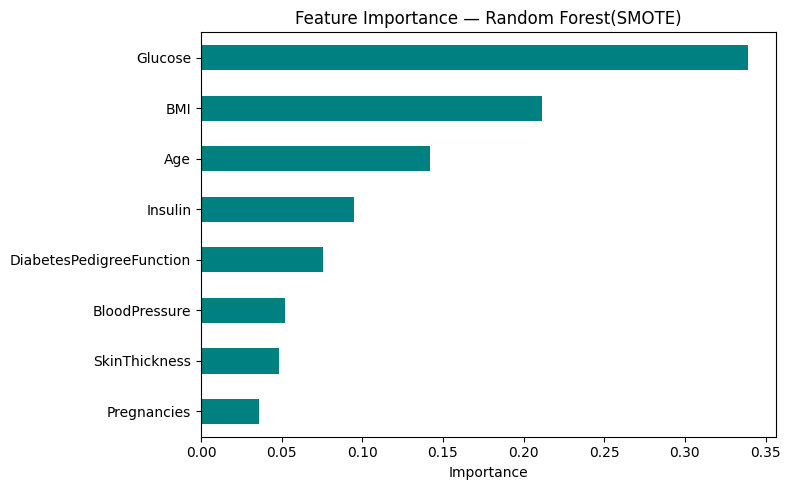

In [19]:
importances = pd.Series(RFModel_SMOTE.feature_importances_, index=X.columns)
plt.figure(figsize=(8, 5))
importances.sort_values().plot(kind="barh", color="teal")
plt.title("Feature Importance — Random Forest(SMOTE)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()